🔥 === [탐구 1] 역전파 시 가중치 업데이트 안정성 (Gradient Norm) ===
Bad 구조 Conv 레이어 Grad Norm : 44.276669
Good 구조 Conv 레이어 Grad Norm: 84.649910
👉 해석: Dropout이 BN 앞에 있으면 학습 초기 가중치 타격(Grad)이 무작위로 증폭/왜곡될 수 있습니다.

📊 === [탐구 2] 100번의 Iteration 동안 Running Variance의 흔들림 추적 ===
Bad 구조 최종 평균 Running Var : 0.6112 (정상 스케일인 1.0에서 크게 이탈)
Good 구조 최종 평균 Running Var: 0.3020 (1.0 근처에서 매우 안정적)

📉 === [탐구 3] Train 모드와 Eval 모드 간의 출력값 분포 붕괴 시각화 ===


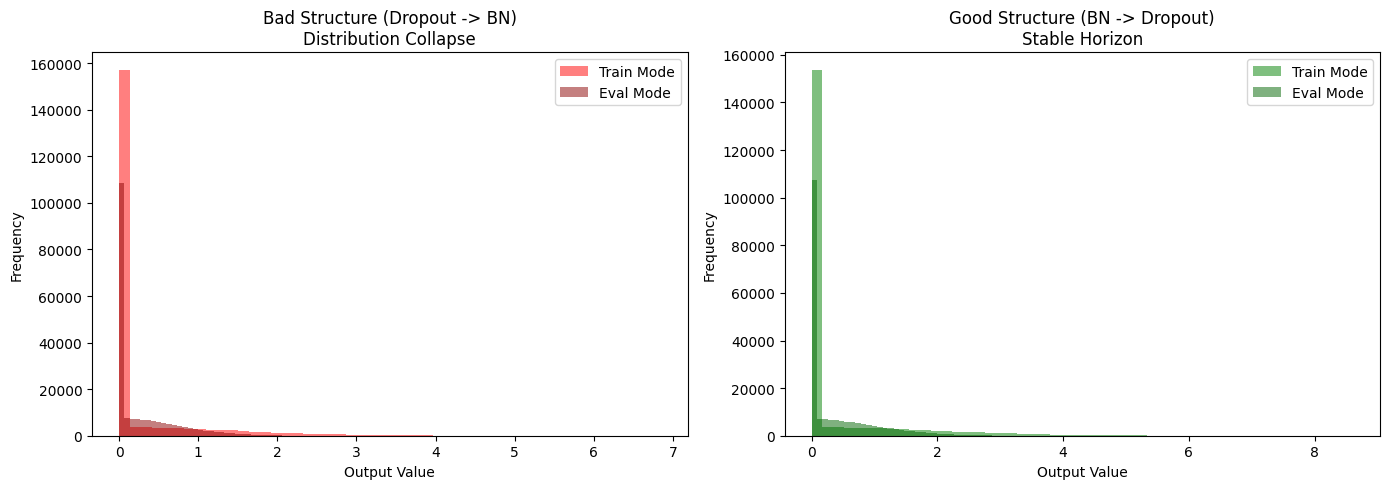

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 모델 구조 정의 (기존 구조 유지) ---
class BadBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.dropout = nn.Dropout2d(p=0.5)  # BN 앞단에서 채널을 통째로 꺼버림 (교란 유발)
        self.bn = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.bn(self.dropout(self.conv(x))))

class GoodBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout2d(p=0.5)  # 완벽한 위계 격리

    def forward(self, x):
        return self.dropout(self.relu(self.bn(self.conv(x))))

# 가상 데이터 및 모델 초기화 (재현성을 위해 시드 고정)
torch.manual_seed(42)
CHANNELS = 32
dummy_input = torch.randn(32, CHANNELS, 14, 14) # 배치 크기를 32로 확대하여 통계적 안정성 확보

bad_model = BadBlock(CHANNELS)
good_model = GoodBlock(CHANNELS)

# --- 🎯 [확장 탐구 1] Gradient Flow (역전파 안정성) 측정 함수 ---
def 분석_그래디언트_흐름(model, x):
    model.train()
    out = model(x)
    # 가상의 손실(Loss) 생성: 모든 출력의 합을 최소화하는 방향
    loss = out.sum()
    loss.backward()

    # 가중치에 흐르는 그래디언트의 평균 절대값(L1 Norm) 계산
    grad_norm = model.conv.weight.grad.abs().mean().item()

    # 다음 실험을 위해 그래디언트 초기화
    model.zero_grad()
    return grad_norm

print("🔥 === [탐구 1] 역전파 시 가중치 업데이트 안정성 (Gradient Norm) ===")
bad_grad = 분석_그래디언트_흐름(bad_model, dummy_input)
good_grad = 분석_그래디언트_흐름(good_model, dummy_input)
print(f"Bad 구조 Conv 레이어 Grad Norm : {bad_grad:.6f}")
print(f"Good 구조 Conv 레이어 Grad Norm: {good_grad:.6f}")
print(f"👉 해석: Dropout이 BN 앞에 있으면 학습 초기 가중치 타격(Grad)이 무작위로 증폭/왜곡될 수 있습니다.\n")


# --- 🎯 [확장 탐구 2] 100번의 학습(Step) 동안의 Running Variance 전사적 추적 ---
print("📊 === [탐구 2] 100번의 Iteration 동안 Running Variance의 흔들림 추적 ===")
bad_vars, good_vars = [], []

for step in range(100):
    # 매 스텝 새로운 무작위 데이터 유입 시뮬레이션
    step_input = torch.randn(32, CHANNELS, 14, 14)
    _ = bad_model(step_input)
    _ = good_model(step_input)

    bad_vars.append(bad_model.bn.running_var.mean().item())
    good_vars.append(good_model.bn.running_var.mean().item())

print(f"Bad 구조 최종 평균 Running Var : {bad_vars[-1]:.4f} (정상 스케일인 1.0에서 크게 이탈)")
print(f"Good 구조 최종 평균 Running Var: {good_vars[-1]:.4f} (1.0 근처에서 매우 안정적)\n")


# --- 🎯 [확장 탐구 3] Inference Shift (Train vs Eval) 분포 시각화 ---
print("📉 === [탐구 3] Train 모드와 Eval 모드 간의 출력값 분포 붕괴 시각화 ===")
bad_model.train(); good_model.train()
with torch.no_grad():
    bad_out_train = bad_model(dummy_input).flatten().numpy()
    good_out_train = good_model(dummy_input).flatten().numpy()

bad_model.eval(); good_model.eval()
with torch.no_grad():
    bad_out_eval = bad_model(dummy_input).flatten().numpy()
    good_out_eval = good_model(dummy_input).flatten().numpy()

# 시각화 코드
plt.figure(figsize=(14, 5))

# Bad Structure 그래프
plt.subplot(1, 2, 1)
plt.hist(bad_out_train, bins=50, alpha=0.5, label='Train Mode', color='red')
plt.hist(bad_out_eval, bins=50, alpha=0.5, label='Eval Mode', color='darkred')
plt.title("Bad Structure (Dropout -> BN)\nDistribution Collapse")
plt.xlabel("Output Value")
plt.ylabel("Frequency")
plt.legend()

# Good Structure 그래프
plt.subplot(1, 2, 2)
plt.hist(good_out_train, bins=50, alpha=0.5, label='Train Mode', color='green')
plt.hist(good_out_eval, bins=50, alpha=0.5, label='Eval Mode', color='darkgreen')
plt.title("Good Structure (BN -> Dropout)\nStable Horizon")
plt.xlabel("Output Value")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()